# Load Dataset & Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("saas_user_behavior_dataset.csv")

# Show first 5 rows
print(df.head())

# Check shape
print("Dataset Shape:", df.shape)

# Check column names
print(df.columns)

# Dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

  user_id session_id         event_name      event_timestamp  \
0   U0001    S770487            Landing  2025-05-23 21:00:00   
1   U0001    S770487            Sign-up  2025-05-21 04:00:00   
2   U0001    S770487         Onboarding  2025-05-22 05:00:00   
3   U0001    S770487  First Feature Use  2025-05-23 23:00:00   
4   U0002    S331148            Landing  2025-01-04 20:00:00   

  acquisition_channel signup_month device_type   country trial_status  \
0             Organic      2025-05     Desktop       USA      Expired   
1             Organic      2025-05     Desktop  Pakistan       Active   
2             Organic      2025-05      Tablet       USA       Active   
3             Organic      2025-05     Desktop       USA      Expired   
4             Organic      2025-01      Tablet        UK      Expired   

  plan_type  
0      Free  
1      Free  
2      Free  
3      Free  
4      Free  
Dataset Shape: (2074, 10)
Index(['user_id', 'session_id', 'event_name', 'event_timestamp',
 

# Clean Raw Event Data

In [3]:
# -------------------------------
# DATA CLEANING
# -------------------------------

# Make a copy of original dataset
clean_df = df.copy()

# Check missing values before cleaning
print("Missing Values Before Cleaning:")
print(clean_df.isnull().sum())

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(clean_df.shape)

# Handle missing values
# Fill missing device_type and country

clean_df['device_type'] = clean_df['device_type'].fillna('Unknown')
clean_df['country'] = clean_df['country'].fillna('Unknown')

# Convert timestamp into datetime format
clean_df['event_timestamp'] = pd.to_datetime(
    clean_df['event_timestamp']
)

# Check missing values after cleaning
print("\nMissing Values After Cleaning:")
print(clean_df.isnull().sum())

# Check duplicates again
print("\nDuplicate Rows Remaining:")
print(clean_df.duplicated().sum())

# Save cleaned dataset
clean_df.to_csv(
    "cleaned_saas_user_behavior_dataset.csv",
    index=False
)

print("\nCleaning Completed Successfully!")

Missing Values Before Cleaning:
user_id                 0
session_id              0
event_name              0
event_timestamp         0
acquisition_channel     0
signup_month            0
device_type            20
country                20
trial_status            0
plan_type               0
dtype: int64

Shape After Removing Duplicates:
(2030, 10)

Missing Values After Cleaning:
user_id                0
session_id             0
event_name             0
event_timestamp        0
acquisition_channel    0
signup_month           0
device_type            0
country                0
trial_status           0
plan_type              0
dtype: int64

Duplicate Rows Remaining:
0

Cleaning Completed Successfully!


# Define Funnel

In [4]:
# --------------------------------
# DEFINE FUNNEL STEPS
# --------------------------------

funnel_steps = [
    'Landing',
    'Sign-up',
    'Onboarding',
    'First Feature Use',
    'Upgrade'
]

# Count unique users at each step
funnel_counts = []

for step in funnel_steps:
    users = clean_df[
        clean_df['event_name'] == step
    ]['user_id'].nunique()

    funnel_counts.append(users)

# Create funnel dataframe
funnel_df = pd.DataFrame({
    'Step': funnel_steps,
    'Users': funnel_counts
})

print(funnel_df)

                Step  Users
0            Landing    700
1            Sign-up    528
2         Onboarding    405
3  First Feature Use    293
4            Upgrade     98


# Calculate Conversion Rate

In [5]:
# --------------------------------
# CONVERSION RATE
# --------------------------------

conversion_rates = [100]

for i in range(1, len(funnel_counts)):
    rate = (
        funnel_counts[i] /
        funnel_counts[i - 1]
    ) * 100

    conversion_rates.append(rate)

funnel_df['Conversion_Rate (%)'] = conversion_rates

print(funnel_df)

                Step  Users  Conversion_Rate (%)
0            Landing    700           100.000000
1            Sign-up    528            75.428571
2         Onboarding    405            76.704545
3  First Feature Use    293            72.345679
4            Upgrade     98            33.447099


# Calculate Drop-Off Rate

In [6]:
# --------------------------------
# DROP-OFF RATE
# --------------------------------

drop_off_rates = [0]

for i in range(1, len(funnel_counts)):
    drop = 100 - conversion_rates[i]
    drop_off_rates.append(drop)

funnel_df['Drop_Off (%)'] = drop_off_rates

print(funnel_df)

                Step  Users  Conversion_Rate (%)  Drop_Off (%)
0            Landing    700           100.000000      0.000000
1            Sign-up    528            75.428571     24.571429
2         Onboarding    405            76.704545     23.295455
3  First Feature Use    293            72.345679     27.654321
4            Upgrade     98            33.447099     66.552901


# Funnel Users Visualization

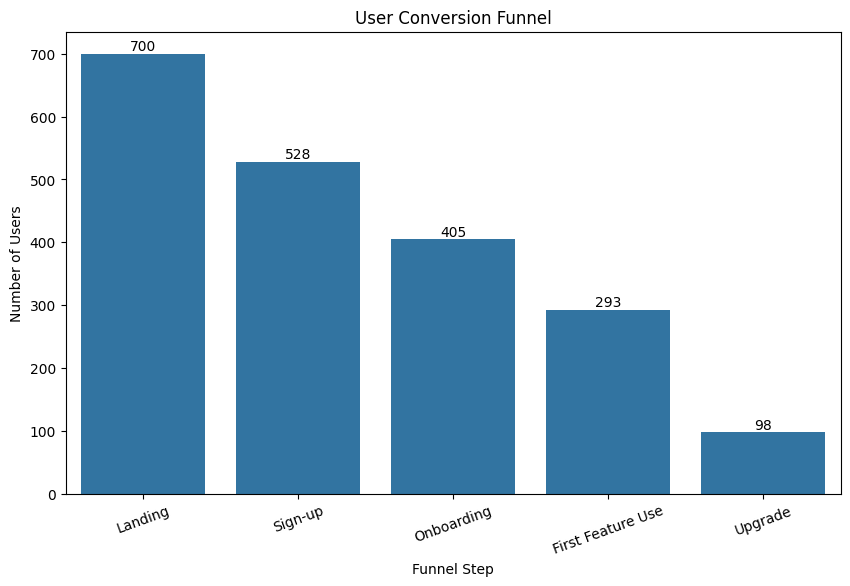

In [7]:
# --------------------------------
# FUNNEL USERS CHART
# --------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x='Step',
    y='Users',
    data=funnel_df
)

plt.title('User Conversion Funnel')
plt.xlabel('Funnel Step')
plt.ylabel('Number of Users')

plt.xticks(rotation=20)

for i, value in enumerate(funnel_df['Users']):
    plt.text(i, value + 5, str(value),
             ha='center',
             fontsize=10)

plt.show()

# Conversion Rate Chart

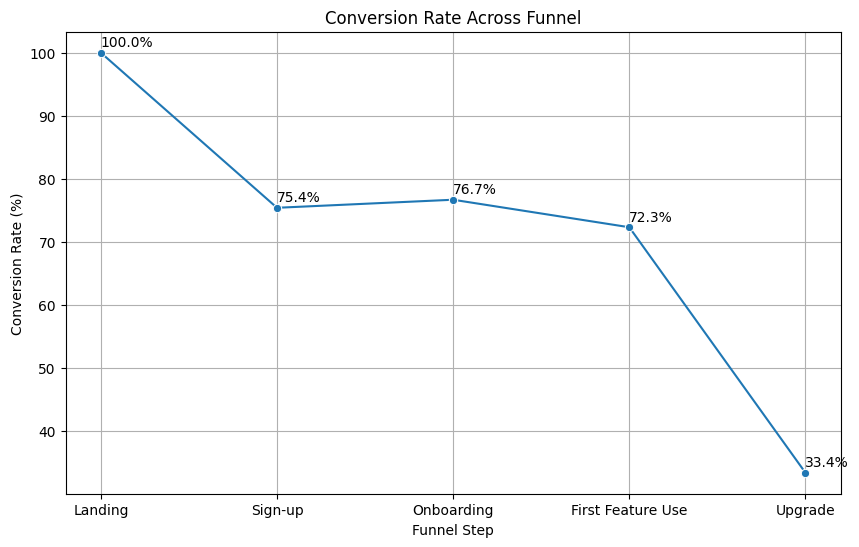

In [8]:
# --------------------------------
# CONVERSION RATE CHART
# --------------------------------

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Step',
    y='Conversion_Rate (%)',
    data=funnel_df,
    marker='o'
)

plt.title('Conversion Rate Across Funnel')
plt.xlabel('Funnel Step')
plt.ylabel('Conversion Rate (%)')

plt.grid(True)

for i, value in enumerate(
    funnel_df['Conversion_Rate (%)']
):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%"
    )

plt.show()

# Drop-Off Rate Chart

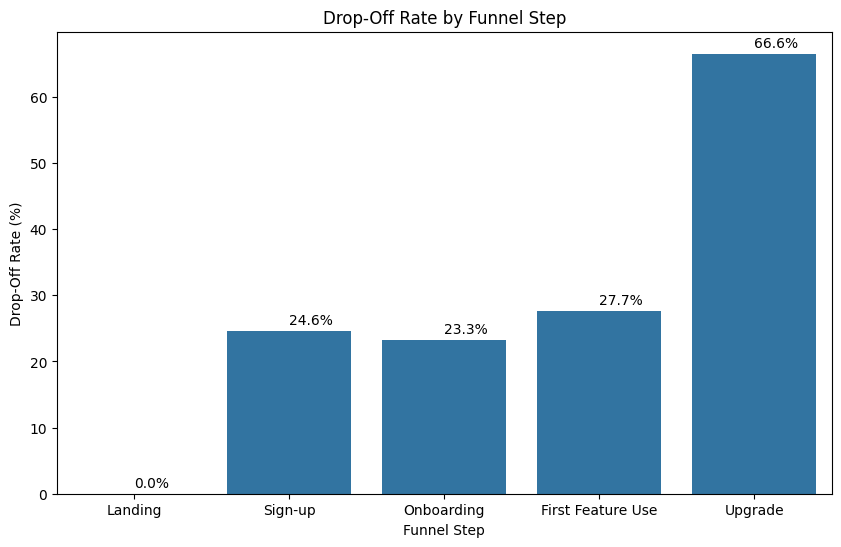

In [9]:
# --------------------------------
# DROP-OFF RATE CHART
# --------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x='Step',
    y='Drop_Off (%)',
    data=funnel_df
)

plt.title('Drop-Off Rate by Funnel Step')
plt.xlabel('Funnel Step')
plt.ylabel('Drop-Off Rate (%)')

for i, value in enumerate(
    funnel_df['Drop_Off (%)']
):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%"
    )

plt.show()

# Save Charts

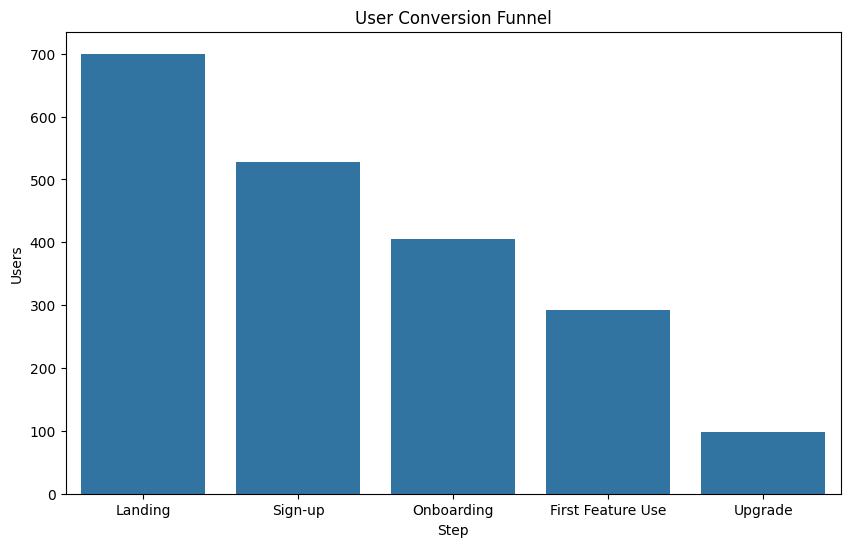

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Step',
    y='Users',
    data=funnel_df
)

plt.title('User Conversion Funnel')

plt.savefig(
    'funnel_chart.png'
)

plt.show()

# Prepare Cohort Data

In [11]:
# --------------------------------
# COHORT ANALYSIS
# --------------------------------

# Convert signup_month to datetime
clean_df['signup_month'] = pd.to_datetime(
    clean_df['signup_month']
)

# Count unique users by cohort
cohort_users = clean_df.groupby(
    clean_df['signup_month'].dt.to_period('M')
)['user_id'].nunique()

print(cohort_users)

signup_month
2025-01    63
2025-02    46
2025-03    61
2025-04    45
2025-05    61
2025-06    64
2025-07    55
2025-08    65
2025-09    69
2025-10    74
2025-11    49
2025-12    47
2026-01     1
Freq: M, Name: user_id, dtype: int64


# Cohort Funnel Performance

In [12]:
# --------------------------------
# MONTHLY UPGRADES
# --------------------------------

upgrade_users = clean_df[
    clean_df['event_name'] == 'Upgrade'
]

cohort_upgrade = upgrade_users.groupby(
    upgrade_users['signup_month'].dt.to_period('M')
)['user_id'].nunique()

print(cohort_upgrade)

signup_month
2025-01     6
2025-02    11
2025-03    13
2025-04     3
2025-05    10
2025-06     8
2025-07     5
2025-08     9
2025-09    11
2025-10    11
2025-11     8
2025-12     3
Freq: M, Name: user_id, dtype: int64


# Cohort Retention Table

In [13]:
# --------------------------------
# COHORT PERFORMANCE TABLE
# --------------------------------

cohort_table = pd.DataFrame({
    'Total Users': cohort_users,
    'Upgraded Users': cohort_upgrade
})

# Fill missing values
cohort_table = cohort_table.fillna(0)

# Calculate upgrade rate
cohort_table['Upgrade Rate (%)'] = (
    cohort_table['Upgraded Users']
    / cohort_table['Total Users']
) * 100

print(cohort_table)

              Total Users  Upgraded Users  Upgrade Rate (%)
signup_month                                               
2025-01                63             6.0          9.523810
2025-02                46            11.0         23.913043
2025-03                61            13.0         21.311475
2025-04                45             3.0          6.666667
2025-05                61            10.0         16.393443
2025-06                64             8.0         12.500000
2025-07                55             5.0          9.090909
2025-08                65             9.0         13.846154
2025-09                69            11.0         15.942029
2025-10                74            11.0         14.864865
2025-11                49             8.0         16.326531
2025-12                47             3.0          6.382979
2026-01                 1             0.0          0.000000


# Cohort Visualization

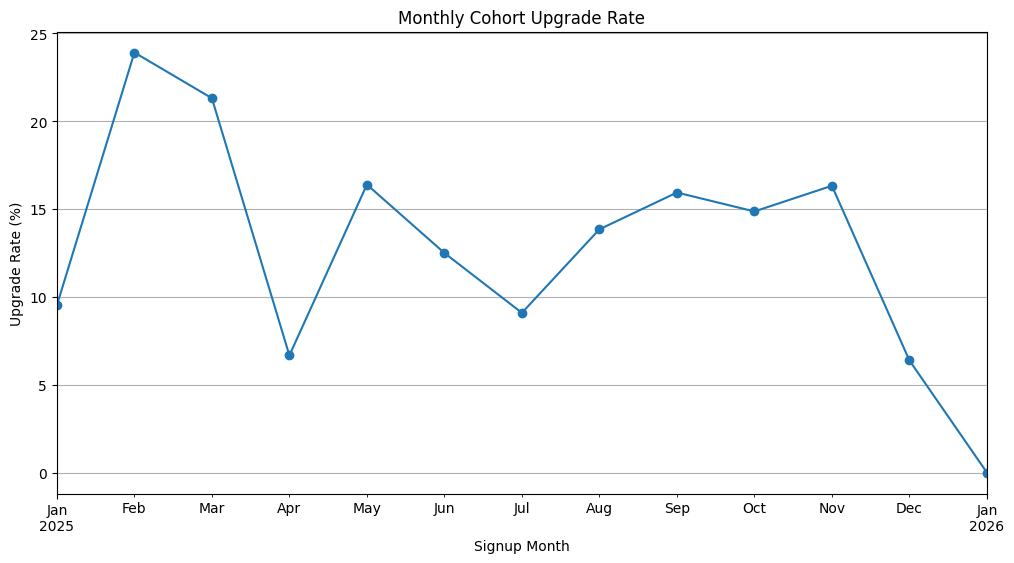

In [14]:
# --------------------------------
# COHORT UPGRADE RATE GRAPH
# --------------------------------

plt.figure(figsize=(12,6))

cohort_table[
    'Upgrade Rate (%)'
].plot(marker='o')

plt.title(
    'Monthly Cohort Upgrade Rate'
)

plt.xlabel('Signup Month')
plt.ylabel('Upgrade Rate (%)')

plt.grid(True)

plt.show()

# Users by Acquisition Channel

In [15]:
# --------------------------------
# USERS BY CHANNEL
# --------------------------------

channel_users = clean_df.groupby(
    'acquisition_channel'
)['user_id'].nunique()

print(channel_users)

acquisition_channel
Organic     330
Paid        231
Referral    139
Name: user_id, dtype: int64


# Upgraded Users by Channel

In [16]:
# --------------------------------
# UPGRADED USERS BY CHANNEL
# --------------------------------

upgrade_channel = clean_df[
    clean_df['event_name'] == 'Upgrade'
]

channel_upgrade = upgrade_channel.groupby(
    'acquisition_channel'
)['user_id'].nunique()

print(channel_upgrade)

acquisition_channel
Organic     47
Paid        42
Referral     9
Name: user_id, dtype: int64


# Channel Performance Table

In [17]:
# --------------------------------
# CHANNEL PERFORMANCE TABLE
# --------------------------------

segment_table = pd.DataFrame({
    'Total Users': channel_users,
    'Upgraded Users': channel_upgrade
})

# Replace missing values
segment_table = segment_table.fillna(0)

# Upgrade Rate
segment_table['Upgrade Rate (%)'] = (
    segment_table['Upgraded Users']
    / segment_table['Total Users']
) * 100

print(segment_table)

                     Total Users  Upgraded Users  Upgrade Rate (%)
acquisition_channel                                               
Organic                      330              47         14.242424
Paid                         231              42         18.181818
Referral                     139               9          6.474820


# Visualization

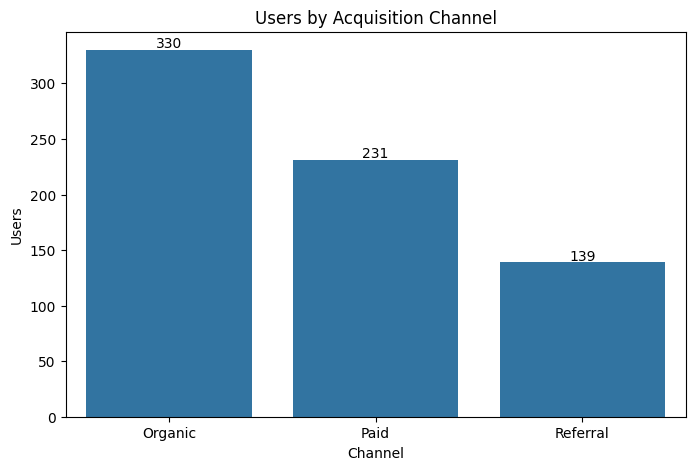

In [18]:
# --------------------------------
# USERS BY CHANNEL GRAPH
# --------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x=channel_users.index,
    y=channel_users.values
)

plt.title('Users by Acquisition Channel')
plt.xlabel('Channel')
plt.ylabel('Users')

for i, value in enumerate(
    channel_users.values
):
    plt.text(i, value + 2,
             str(value),
             ha='center')

plt.show()

# Upgrade Rate by Channel

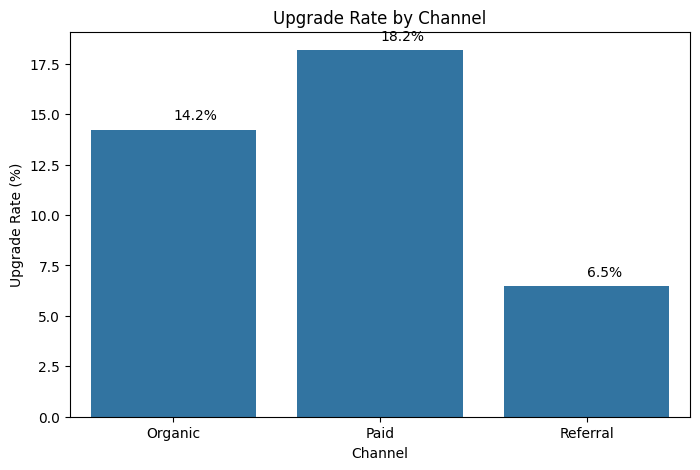

In [19]:
# --------------------------------
# UPGRADE RATE BY CHANNEL
# --------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_table.index,
    y=segment_table[
        'Upgrade Rate (%)'
    ]
)

plt.title(
    'Upgrade Rate by Channel'
)

plt.xlabel('Channel')
plt.ylabel('Upgrade Rate (%)')

for i, value in enumerate(
    segment_table[
        'Upgrade Rate (%)'
    ]
):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%"
    )

plt.show()

# Dashboard Layout

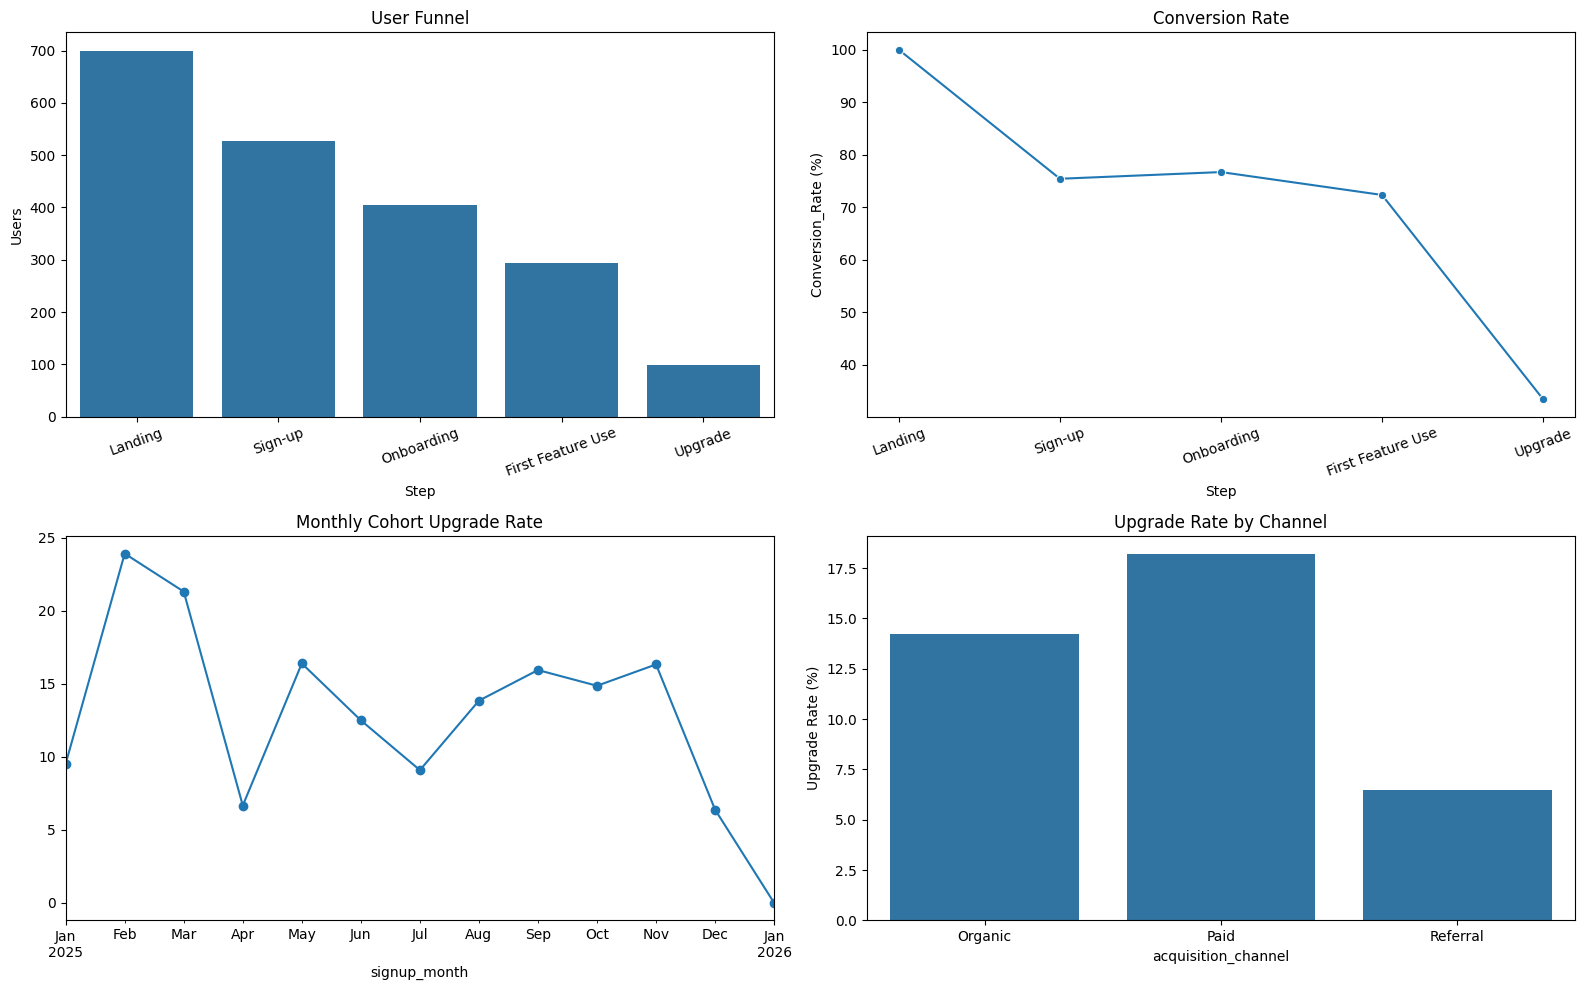

In [20]:
# --------------------------------
# DASHBOARD VISUALIZATION
# --------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(16,10)
)

# --------------------------------
# 1. Funnel Users
# --------------------------------
sns.barplot(
    x='Step',
    y='Users',
    data=funnel_df,
    ax=axes[0,0]
)

axes[0,0].set_title(
    'User Funnel'
)

axes[0,0].tick_params(
    axis='x',
    rotation=20
)

# --------------------------------
# 2. Conversion Rate
# --------------------------------
sns.lineplot(
    x='Step',
    y='Conversion_Rate (%)',
    data=funnel_df,
    marker='o',
    ax=axes[0,1]
)

axes[0,1].set_title(
    'Conversion Rate'
)

axes[0,1].tick_params(
    axis='x',
    rotation=20
)

# --------------------------------
# 3. Cohort Upgrade Rate
# --------------------------------
cohort_table[
    'Upgrade Rate (%)'
].plot(
    marker='o',
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Monthly Cohort Upgrade Rate'
)

# --------------------------------
# 4. Channel Upgrade Rate
# --------------------------------
sns.barplot(
    x=segment_table.index,
    y=segment_table[
        'Upgrade Rate (%)'
    ],
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Upgrade Rate by Channel'
)

plt.tight_layout()

plt.show()

# Save Dashboard Image

In [21]:
fig.savefig(
    "saas_dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

print(
    "Dashboard saved successfully!"
)

Dashboard saved successfully!


# Export Final Analysis Tables

In [22]:
# Save funnel table
funnel_df.to_csv(
    'funnel_analysis.csv',
    index=False
)

# Save cohort table
cohort_table.to_csv(
    'cohort_analysis.csv'
)

# Save segmentation table
segment_table.to_csv(
    'segmentation_analysis.csv'
)

print("Files Saved!")

Files Saved!


# customer churn prediction work

# Create User-Level Dataset

In [23]:
# --------------------------------
# USER LEVEL DATA FOR CHURN
# --------------------------------

user_df = clean_df.groupby(
    'user_id'
).agg({
    'acquisition_channel': 'first',
    'device_type': 'first',
    'country': 'first',
    'trial_status': 'first'
}).reset_index()

# Create target variable
upgrade_users = clean_df[
    clean_df['event_name']
    == 'Upgrade'
]['user_id'].unique()

# Churn = 1 if NOT upgraded
user_df['churn'] = (
    ~user_df['user_id']
    .isin(upgrade_users)
).astype(int)

print(user_df.head())

  user_id acquisition_channel device_type   country trial_status  churn
0   U0001             Organic     Desktop       USA      Expired      1
1   U0002             Organic      Tablet        UK      Expired      1
2   U0003             Organic      Mobile  Pakistan      Expired      1
3   U0004             Organic     Desktop  Pakistan      Expired      1
4   U0005             Organic      Tablet     India       Active      1


# Encode Categorical Features

In [24]:
# --------------------------------
# LABEL ENCODING
# --------------------------------

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = [
    'acquisition_channel',
    'device_type',
    'country',
    'trial_status'
]

for col in categorical_cols:
    user_df[col] = encoder.fit_transform(
        user_df[col]
    )

print(user_df.head())

  user_id  acquisition_channel  device_type  country  trial_status  churn
0   U0001                    0            0        4             1      1
1   U0002                    0            2        3             1      1
2   U0003                    0            1        1             1      1
3   U0004                    0            0        1             1      1
4   U0005                    0            2        0             0      1


# Split Features and Target

In [25]:
# --------------------------------
# FEATURES & TARGET
# --------------------------------

X = user_df.drop(
    ['user_id', 'churn'],
    axis=1
)

y = user_df['churn']

print(X.head())
print(y.head())

   acquisition_channel  device_type  country  trial_status
0                    0            0        4             1
1                    0            2        3             1
2                    0            1        1             1
3                    0            0        1             1
4                    0            2        0             0
0    1
1    1
2    1
3    1
4    1
Name: churn, dtype: int64


# Train/Test Split

In [27]:
# --------------------------------
# TRAIN TEST SPLIT
# --------------------------------

from sklearn.model_selection import (
    train_test_split
)

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

print(X_train.shape)
print(X_test.shape)

(560, 4)
(140, 4)


# Train Random Forest Model

In [28]:
# --------------------------------
# RANDOM FOREST MODEL
# --------------------------------

from sklearn.ensemble import (
    RandomForestClassifier
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully!")

Model Trained Successfully!


# Prediction & Accuracy

In [29]:
# --------------------------------
# PREDICTIONS
# --------------------------------

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 85.71 %
              precision    recall  f1-score   support

           0       0.20      0.06      0.09        17
           1       0.88      0.97      0.92       123

    accuracy                           0.86       140
   macro avg       0.54      0.51      0.51       140
weighted avg       0.80      0.86      0.82       140



# Confusion Matrix

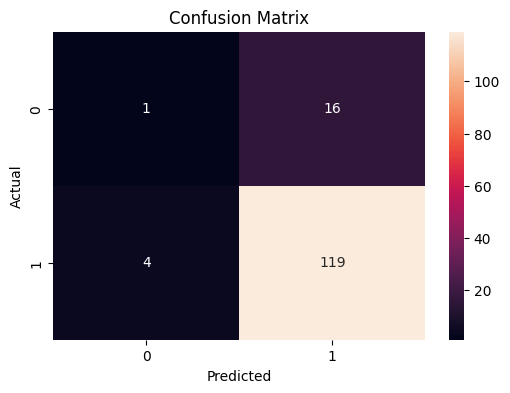

In [30]:
# --------------------------------
# CONFUSION MATRIX
# --------------------------------

from sklearn.metrics import (
    confusion_matrix
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

# Feature Importance

               Feature  Importance
2              country    0.419368
1          device_type    0.260425
0  acquisition_channel    0.207186
3         trial_status    0.113020


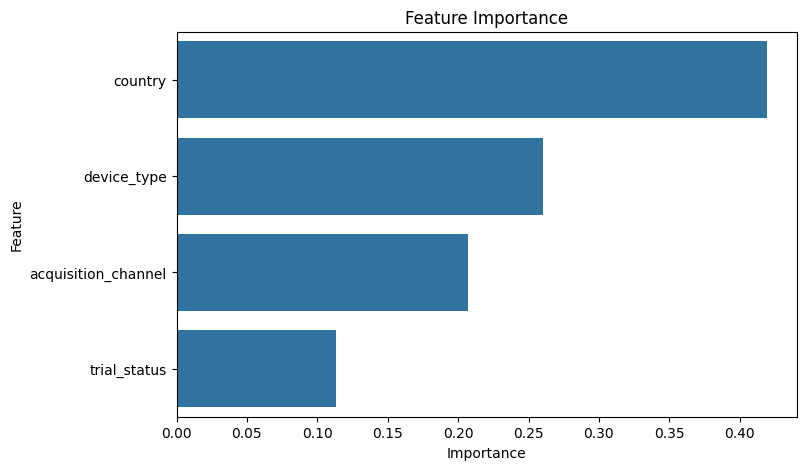

In [31]:
# --------------------------------
# FEATURE IMPORTANCE
# --------------------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    'Feature Importance'
)

plt.show()